# NexoAnalytics — Análisis Exploratorio de Datos (EDA)

**Objetivo:** Explorar secuencias de ADN concatenadas (16S + COI + ITS1) de ostiones para detectar señales de hibridación e introgresión entre *Crassostrea gigas* y *Saccostrea palmula*.

**Datos:**
- `secuencias_referencias.fasta` — 12 secuencias: outgroups, referencias de especie, híbridos (m13, m14) e introgresados (m04–m06)
- `secuencias_muestras.fasta` — 20 muestras de campo: 10 *S. palmula* (Sp1–Sp10) y 10 *C. gigas* (Cg1–Cg10)

**Enfoque:** Tratar secuencias como texto (NLP con k-mers), vectorizar y aplicar métodos estadísticos.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from itertools import product
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

## 0. Carga de datos

In [2]:
def parse_fasta(filepath):
    """Lee un archivo FASTA y devuelve dict {id: secuencia}."""
    sequences = {}
    current_id = None
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('"'):
                continue
            if line.startswith('>'):
                current_id = line[1:]
                sequences[current_id] = []
            elif current_id:
                sequences[current_id].append(line)
    return {k: ''.join(v).upper() for k, v in sequences.items()}

refs = parse_fasta('../data/raw/secuencias_referencias.fasta')
muestras = parse_fasta('../data/raw/secuencias_muestras.fasta')

print(f"Referencias: {len(refs)} secuencias")
print(f"Muestras:    {len(muestras)} secuencias")
print(f"Total:       {len(refs) + len(muestras)} secuencias")

Referencias: 12 secuencias
Muestras:    20 secuencias
Total:       32 secuencias


In [3]:
# Asignar grupo biológico a cada secuencia
def assign_group(seq_id):
    if seq_id in ('N_cochlear', 'H_hyotis'):
        return 'Outgroup'
    elif seq_id in ('S_palmula', 'S_kegaki', 'S_cucullata', 'S_glomerata'):
        return 'Saccostrea (ref)'
    elif seq_id == 'C_gigas':
        return 'C. gigas (ref)'
    elif seq_id in ('S_palmula_m13', 'S_palmula_m14'):
        return 'Híbrido'
    elif seq_id in ('S_palmula_m04', 'S_palmula_m05', 'S_palmula_m06'):
        return 'Introgresado'
    elif seq_id.startswith('Sp'):
        return 'S. palmula (campo)'
    elif seq_id.startswith('Cg'):
        return 'C. gigas (campo)'
    return 'Desconocido'

# Combinar todos los datos
all_seqs = {**refs, **muestras}
groups = {sid: assign_group(sid) for sid in all_seqs}

# Colores por grupo
GROUP_COLORS = {
    'Outgroup':           '#999999',
    'Saccostrea (ref)':   '#2ca02c',
    'C. gigas (ref)':     '#1f77b4',
    'Híbrido':            '#ff7f0e',
    'Introgresado':       '#d62728',
    'S. palmula (campo)': '#98df8a',
    'C. gigas (campo)':   '#aec7e8',
}

print("Secuencias por grupo:")
for g in GROUP_COLORS:
    ids = [s for s, gr in groups.items() if gr == g]
    if ids:
        print(f"  {g}: {len(ids)} — {', '.join(ids)}")

Secuencias por grupo:
  Outgroup: 2 — N_cochlear, H_hyotis
  Saccostrea (ref): 4 — S_palmula, S_kegaki, S_cucullata, S_glomerata
  C. gigas (ref): 1 — C_gigas
  Híbrido: 2 — S_palmula_m13, S_palmula_m14
  Introgresado: 3 — S_palmula_m04, S_palmula_m05, S_palmula_m06
  S. palmula (campo): 10 — Sp1, Sp2, Sp3, Sp4, Sp5, Sp6, Sp7, Sp8, Sp9, Sp10
  C. gigas (campo): 10 — Cg1, Cg2, Cg3, Cg4, Cg5, Cg6, Cg7, Cg8, Cg9, Cg10


---
## Capa 1 — Estadísticas básicas de las secuencias

Longitud, composición nucleotídica, contenido GC y caracteres ambiguos.

In [4]:
rows = []
for sid, seq in all_seqs.items():
    length = len(seq)
    counts = Counter(seq)
    n_standard = sum(counts.get(b, 0) for b in 'ACGT')
    ambiguous = {k: v for k, v in counts.items() if k not in 'ACGT'}
    
    rows.append({
        'id': sid,
        'grupo': groups[sid],
        'longitud': length,
        'A': counts.get('A', 0),
        'C': counts.get('C', 0),
        'G': counts.get('G', 0),
        'T': counts.get('T', 0),
        '%A': counts.get('A', 0) / length * 100,
        '%C': counts.get('C', 0) / length * 100,
        '%G': counts.get('G', 0) / length * 100,
        '%T': counts.get('T', 0) / length * 100,
        '%GC': (counts.get('G', 0) + counts.get('C', 0)) / length * 100,
        'n_ambiguos': sum(ambiguous.values()),
        'ambiguos_detalle': str(ambiguous) if ambiguous else '',
    })

df_stats = pd.DataFrame(rows).set_index('id')
df_stats.sort_values('grupo', inplace=True)

# Mostrar tabla resumen
display_cols = ['grupo', 'longitud', '%A', '%C', '%G', '%T', '%GC', 'n_ambiguos', 'ambiguos_detalle']
df_stats[display_cols].round(2)

,grupo,longitud,%A,%C,%G,%T,%GC,n_ambiguos,ambiguos_detalle
id,,,,,,,,,
Cg10,C. gigas (campo),1484,23.92,20.82,24.19,31.06,45.01,0,
Cg8,C. gigas (campo),1477,24.10,20.99,24.17,30.74,45.16,0,
Cg7,C. gigas (campo),1480,24.12,20.81,24.19,30.88,45.00,0,
Cg6,C. gigas (campo),1483,24.07,20.84,24.14,30.95,44.98,0,
Cg5,C. gigas (campo),1481,24.17,20.93,24.17,30.72,45.10,0,
Cg4,C. gigas (campo),1482,24.02,20.85,24.16,30.97,45.01,0,
Cg3,C. gigas (campo),1479,24.14,20.89,24.14,30.83,45.03,0,
Cg2,C. gigas (campo),1480,24.19,20.81,24.12,30.88,44.93,0,
Cg1,C. gigas (campo),1480,24.12,20.81,24.12,30.95,44.93,0,


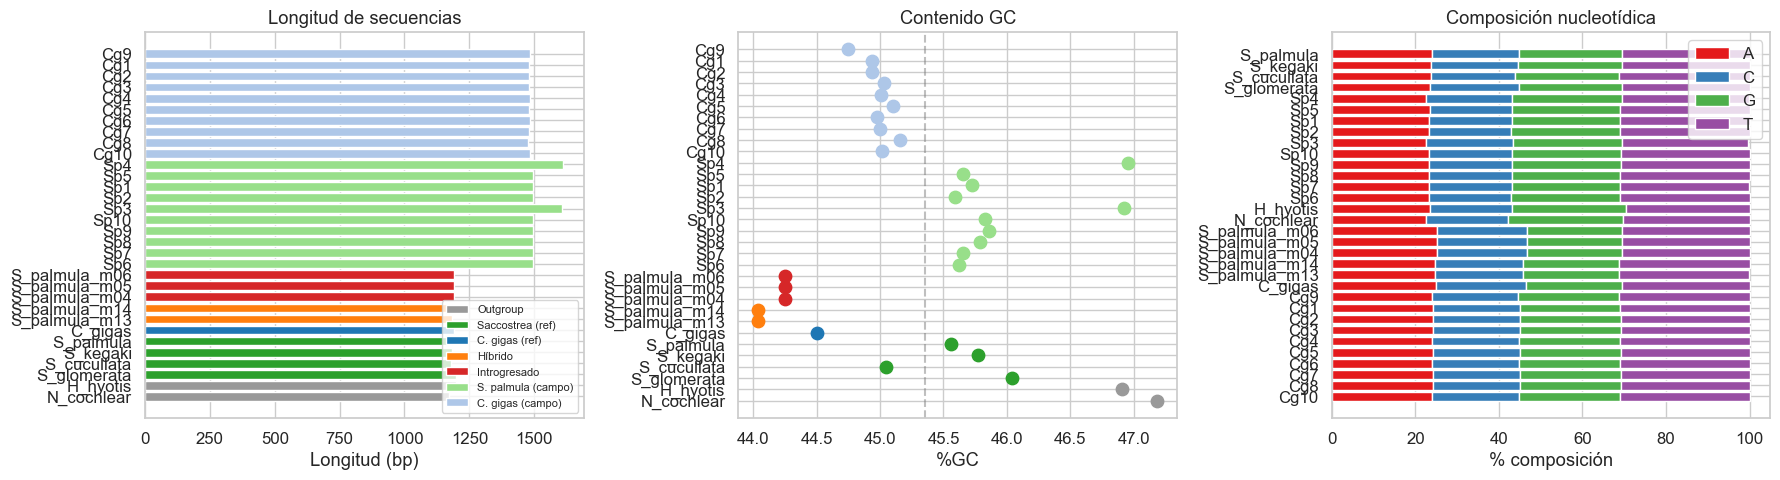

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Longitud por grupo
ax = axes[0]
for g, color in GROUP_COLORS.items():
    subset = df_stats[df_stats['grupo'] == g]
    if len(subset) > 0:
        ax.barh(subset.index, subset['longitud'], color=color, label=g)
ax.set_xlabel('Longitud (bp)')
ax.set_title('Longitud de secuencias')
ax.legend(fontsize=8, loc='lower right')

# 2. %GC por grupo
ax = axes[1]
for g, color in GROUP_COLORS.items():
    subset = df_stats[df_stats['grupo'] == g]
    if len(subset) > 0:
        ax.scatter(subset['%GC'], subset.index, color=color, s=80, label=g, zorder=3)
ax.axvline(df_stats['%GC'].mean(), color='gray', ls='--', alpha=0.5)
ax.set_xlabel('%GC')
ax.set_title('Contenido GC')

# 3. Composición nucleotídica apilada
ax = axes[2]
bottom = np.zeros(len(df_stats))
for base, color in [('A', '#e41a1c'), ('C', '#377eb8'), ('G', '#4daf4a'), ('T', '#984ea3')]:
    vals = df_stats[f'%{base}'].values
    ax.barh(df_stats.index, vals, left=bottom, color=color, label=base)
    bottom += vals
ax.set_xlabel('% composición')
ax.set_title('Composición nucleotídica')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/capa1_estadisticas_basicas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Capa 2 — Similitud global entre secuencias

Matriz de distancias por k-mers (coseno) y clustering jerárquico.

In [6]:
def kmer_frequencies(seq, k):
    """Calcula frecuencias relativas de k-mers para una secuencia."""
    # Solo considerar bases estándar en la ventana
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)
             if all(b in 'ACGT' for b in seq[i:i+k])]
    total = len(kmers)
    counts = Counter(kmers)
    # Vector ordenado con todas las posibles combinaciones
    all_kmers = [''.join(p) for p in product('ACGT', repeat=k)]
    return np.array([counts.get(km, 0) / total if total > 0 else 0 for km in all_kmers])

def build_kmer_matrix(sequences, k):
    """Construye la matriz de frecuencias de k-mers (individuos x k-mers)."""
    ids = list(sequences.keys())
    all_kmers = [''.join(p) for p in product('ACGT', repeat=k)]
    matrix = np.array([kmer_frequencies(sequences[sid], k) for sid in ids])
    return pd.DataFrame(matrix, index=ids, columns=all_kmers)

In [7]:
# Usar k=4 para la matriz de distancias inicial
K_DIST = 4
kmer_mat = build_kmer_matrix(all_seqs, K_DIST)

# Distancia coseno entre todos los pares
dist_cos = pdist(kmer_mat.values, metric='cosine')
dist_matrix = pd.DataFrame(
    squareform(dist_cos),
    index=kmer_mat.index,
    columns=kmer_mat.index
)

print(f"Matriz de distancias (coseno, k={K_DIST}): {dist_matrix.shape}")
dist_matrix.round(4).head()

Matriz de distancias (coseno, k=4): (32, 32)


,N_cochlear,H_hyotis,S_palmula,S_kegaki,S_cucullata,S_glomerata,C_gigas,S_palmula_m13,S_palmula_m14,S_palmula_m04,...,Cg1,Cg2,Cg3,Cg4,Cg5,Cg6,Cg7,Cg8,Cg9,Cg10
N_cochlear,0.0000,0.1043,0.1498,0.1477,0.1630,0.1602,0.1355,0.1410,0.1414,0.1402,...,0.1238,0.1206,0.1215,0.1194,0.1202,0.1202,0.1194,0.1241,0.1195,0.1186
H_hyotis,0.1043,0.0000,0.1133,0.1075,0.1099,0.1071,0.1246,0.1167,0.1160,0.1228,...,0.1119,0.1124,0.1134,0.1122,0.1134,0.1124,0.1128,0.1155,0.1145,0.1118
S_palmula,0.1498,0.1133,0.0000,0.0313,0.0443,0.0384,0.0904,0.0730,0.0731,0.0877,...,0.0775,0.0761,0.0779,0.0777,0.0765,0.0760,0.0772,0.0807,0.0787,0.0792
S_kegaki,0.1477,0.1075,0.0313,0.0000,0.0364,0.0333,0.0943,0.0739,0.0733,0.0910,...,0.0822,0.0809,0.0835,0.0847,0.0817,0.0812,0.0819,0.0844,0.0826,0.0850
S_cucullata,0.1630,0.1099,0.0443,0.0364,0.0000,0.0402,0.1011,0.0758,0.0747,0.0957,...,0.0919,0.0924,0.0945,0.0942,0.0929,0.0923,0.0945,0.0969,0.0929,0.0943


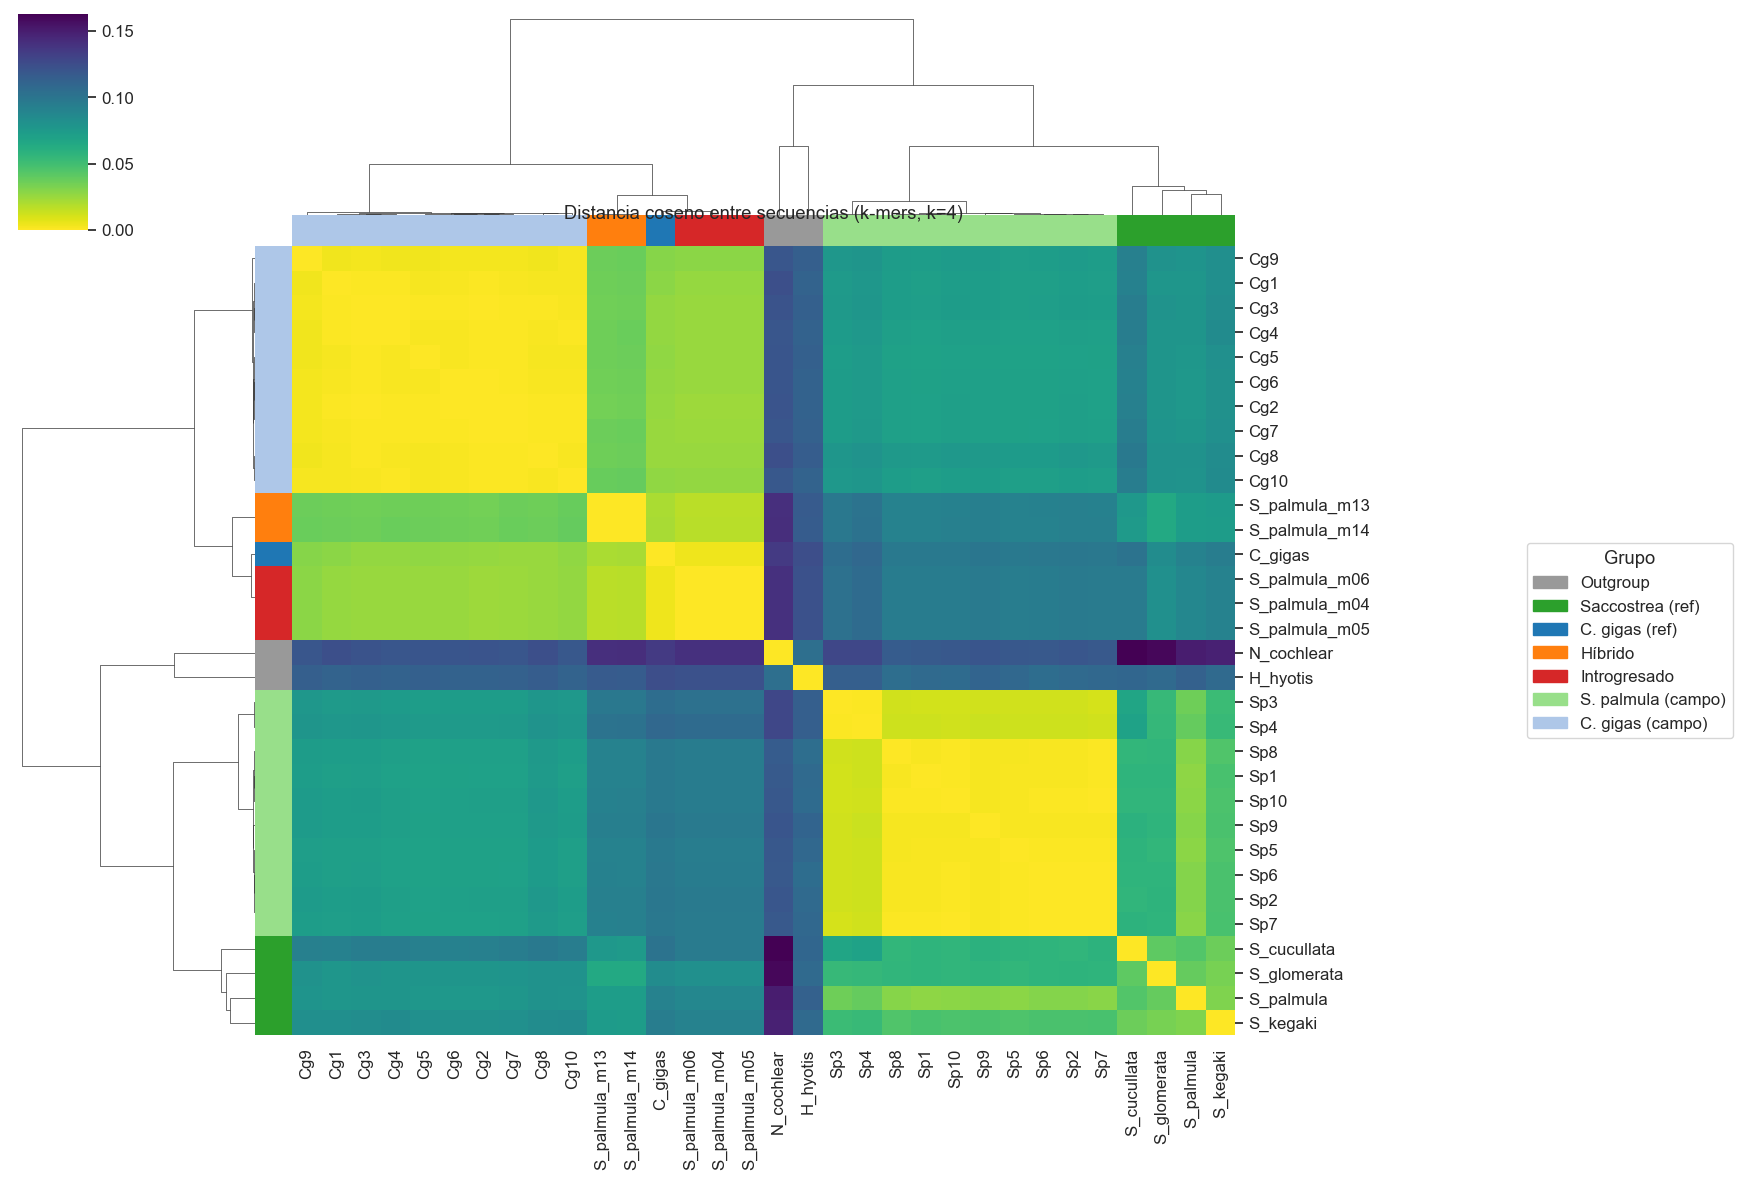

In [8]:
# Heatmap de distancias con dendrograma
linkage_mat = linkage(dist_cos, method='ward')

row_colors = [GROUP_COLORS[groups[sid]] for sid in kmer_mat.index]

g = sns.clustermap(
    dist_matrix,
    row_linkage=linkage_mat,
    col_linkage=linkage_mat,
    row_colors=row_colors,
    col_colors=row_colors,
    cmap='viridis_r',
    figsize=(14, 12),
    xticklabels=True,
    yticklabels=True,
)
g.ax_heatmap.set_title(f'Distancia coseno entre secuencias (k-mers, k={K_DIST})', pad=20)

# Leyenda manual
legend_patches = [mpatches.Patch(color=c, label=g_name) for g_name, c in GROUP_COLORS.items()]
g.ax_heatmap.legend(
    handles=legend_patches, loc='center left',
    bbox_to_anchor=(1.3, 0.5), frameon=True, title='Grupo'
)

plt.savefig('../reports/figures/capa2_heatmap_distancias.png', dpi=150, bbox_inches='tight')
plt.show()

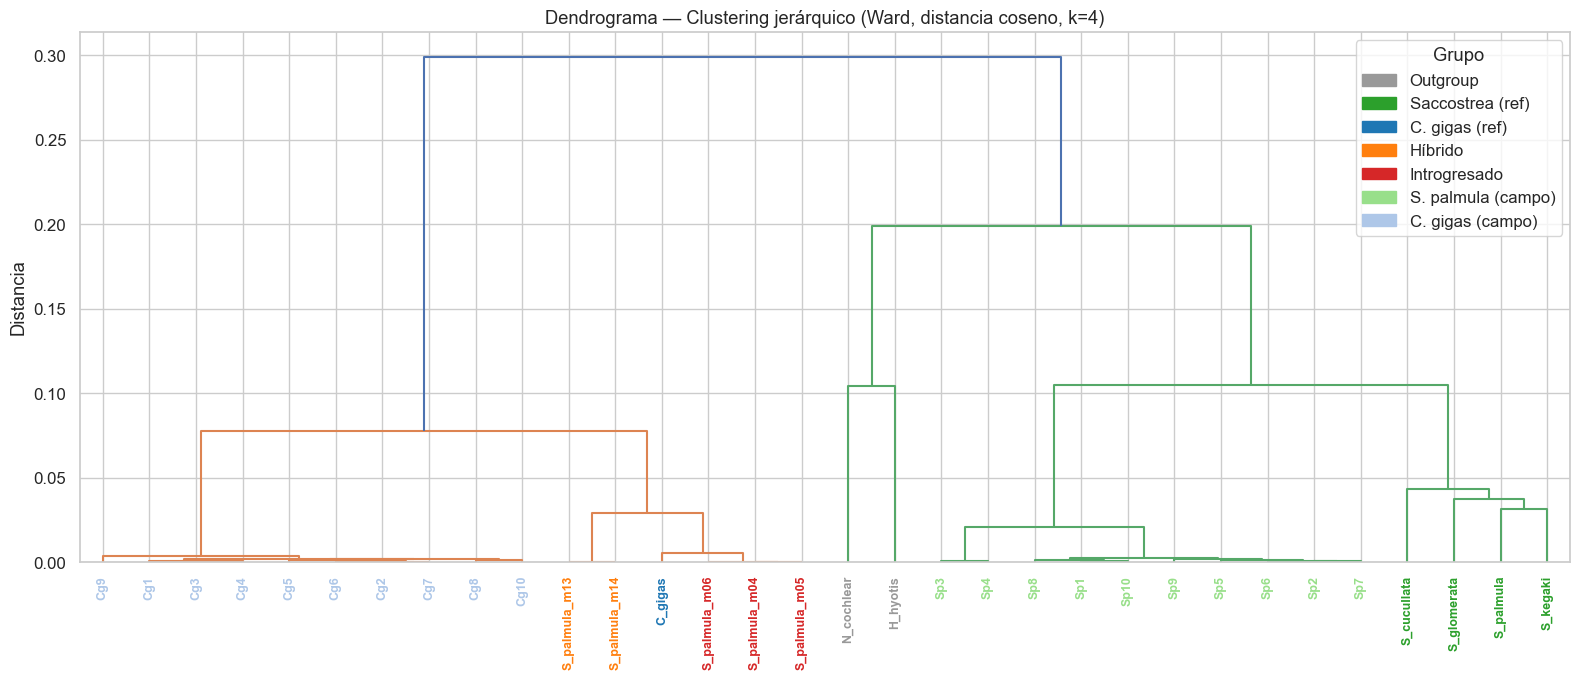

In [9]:
# Dendrograma separado (más legible)
fig, ax = plt.subplots(figsize=(16, 7))

# Colores de hojas según grupo
leaf_colors = {i: GROUP_COLORS[groups[sid]] for i, sid in enumerate(kmer_mat.index)}

def color_func(k):
    """Colorea solo las hojas."""
    return 'black'

dendro = dendrogram(
    linkage_mat,
    labels=list(kmer_mat.index),
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax,
)

# Colorear etiquetas de las hojas
xlbls = ax.get_xticklabels()
for lbl in xlbls:
    sid = lbl.get_text()
    lbl.set_color(GROUP_COLORS.get(groups.get(sid, ''), 'black'))
    lbl.set_fontweight('bold')

ax.set_title(f'Dendrograma — Clustering jerárquico (Ward, distancia coseno, k={K_DIST})')
ax.set_ylabel('Distancia')

legend_patches = [mpatches.Patch(color=c, label=g_name) for g_name, c in GROUP_COLORS.items()]
ax.legend(handles=legend_patches, loc='upper right', frameon=True, title='Grupo')

plt.tight_layout()
plt.savefig('../reports/figures/capa2_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Capa 3 — Vectorización k-mer + PCA (barrido sobre n)

Probar k = 2, 3, 4, 5, 6 y comparar la separación entre grupos.

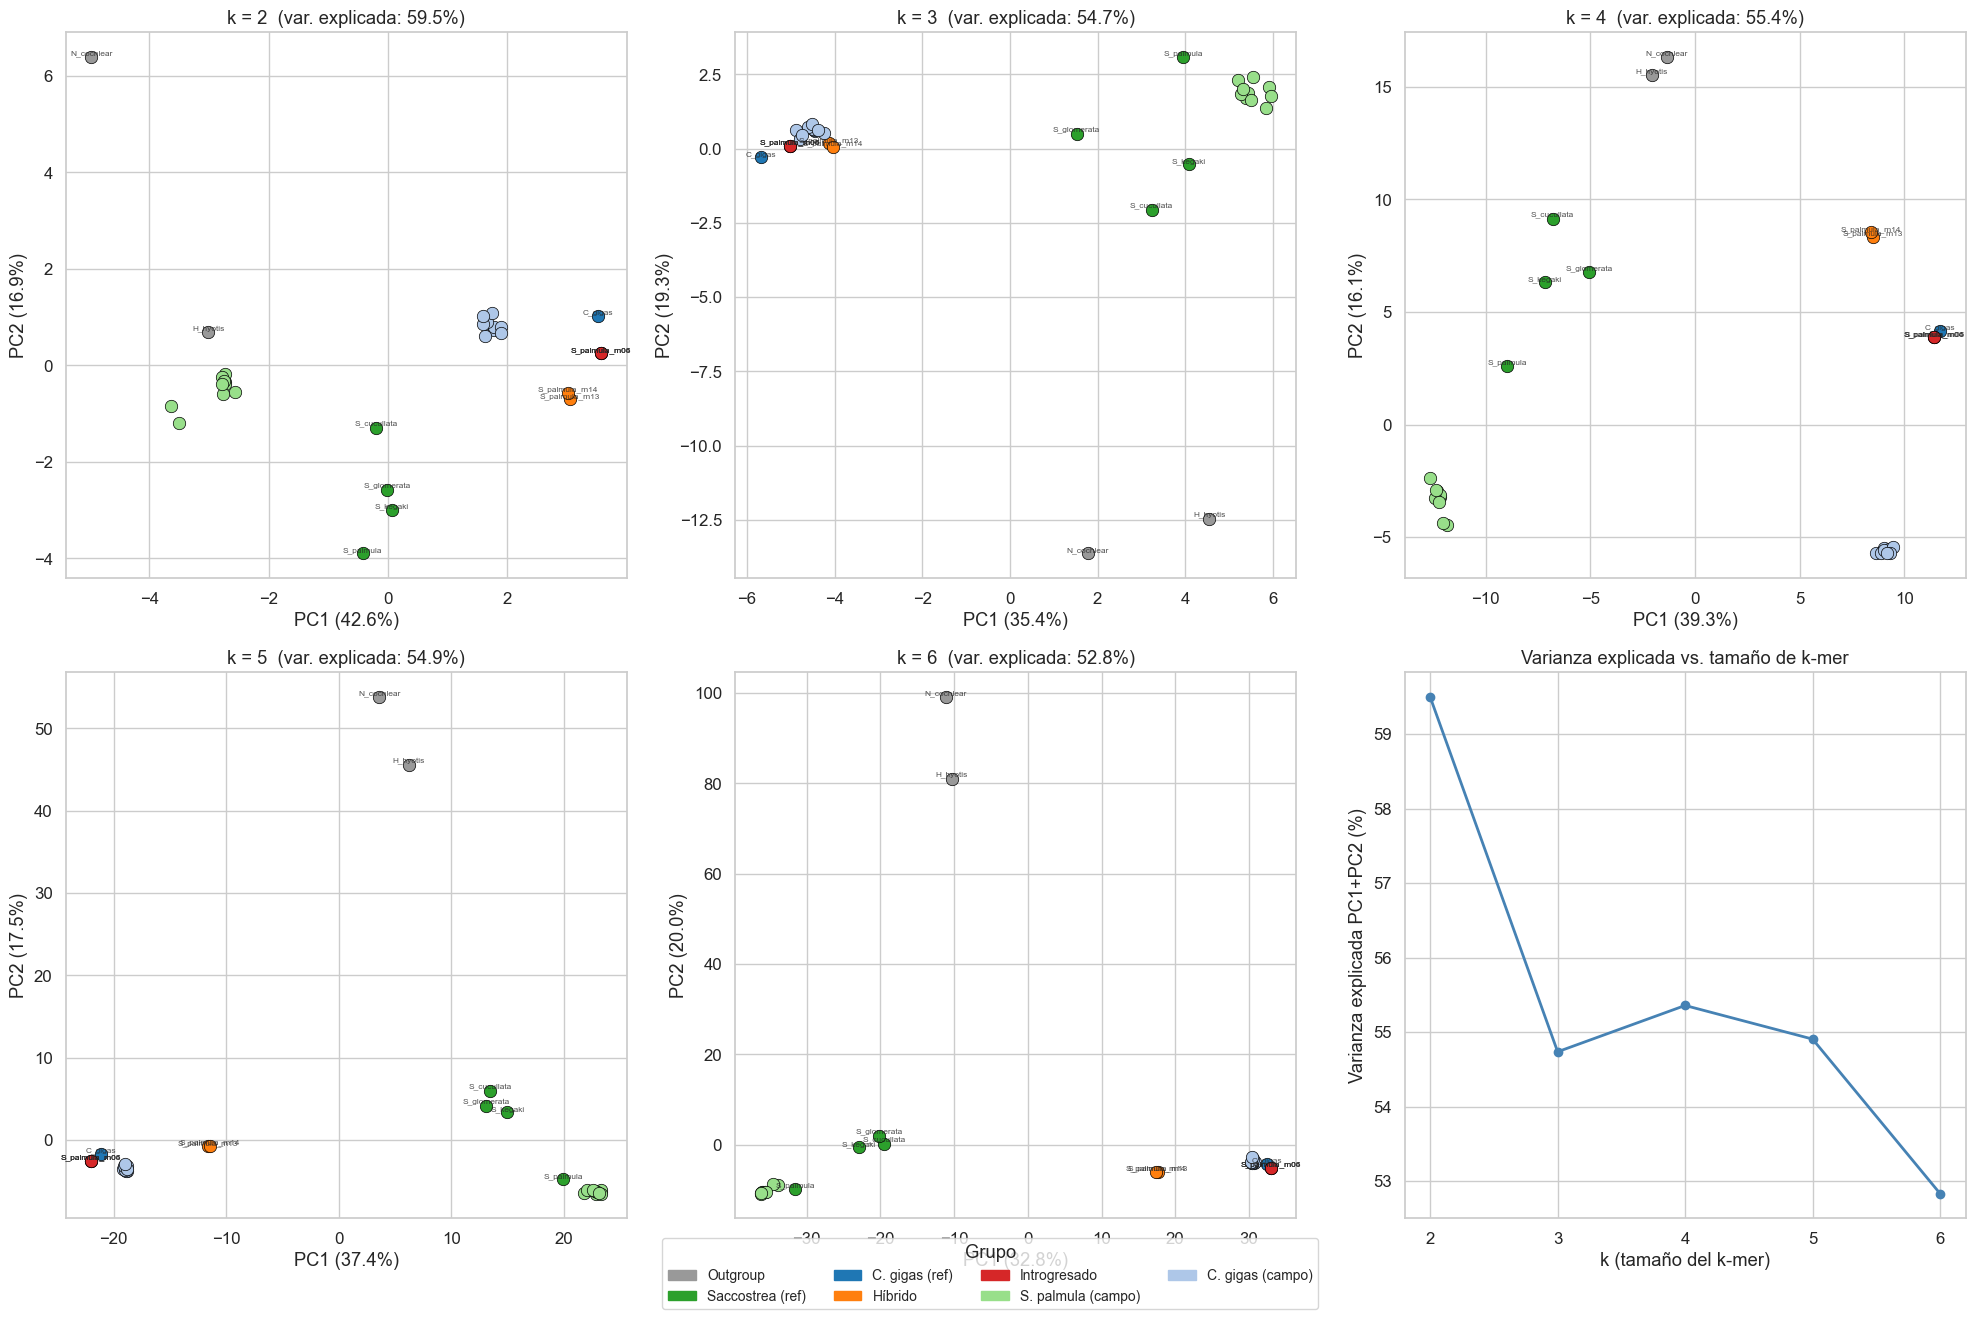

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

variance_explained = {}

for i, k in enumerate([2, 3, 4, 5, 6]):
    ax = axes[i]
    mat = build_kmer_matrix(all_seqs, k)
    
    # Estandarizar antes de PCA
    scaler = StandardScaler()
    mat_scaled = scaler.fit_transform(mat.values)
    
    pca = PCA(n_components=2)
    coords = pca.fit_transform(mat_scaled)
    var_exp = pca.explained_variance_ratio_
    variance_explained[k] = var_exp[0] + var_exp[1]
    
    # Scatter plot
    for g, color in GROUP_COLORS.items():
        mask = [groups[sid] == g for sid in mat.index]
        if any(mask):
            idx_mask = np.where(mask)[0]
            ax.scatter(coords[idx_mask, 0], coords[idx_mask, 1],
                      c=color, label=g, s=80, edgecolors='black', linewidth=0.5, zorder=3)
    
    # Etiquetar puntos especiales (refs, híbridos, introgresados)
    special = [s for s in mat.index if not s.startswith('Sp') and not s.startswith('Cg')]
    for j, sid in enumerate(mat.index):
        if sid in special:
            ax.annotate(sid, (coords[j, 0], coords[j, 1]),
                       fontsize=6, ha='center', va='bottom', alpha=0.8)
    
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
    ax.set_title(f'k = {k}  (var. explicada: {(var_exp[0]+var_exp[1])*100:.1f}%)')

# Última celda: varianza explicada vs k
ax = axes[5]
ks = sorted(variance_explained.keys())
ax.plot(ks, [variance_explained[k]*100 for k in ks], 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('k (tamaño del k-mer)')
ax.set_ylabel('Varianza explicada PC1+PC2 (%)')
ax.set_title('Varianza explicada vs. tamaño de k-mer')
ax.set_xticks(ks)

# Leyenda compartida
handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=True,
           fontsize=10, title='Grupo', bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('../reports/figures/capa3_pca_barrido_k.png', dpi=150, bbox_inches='tight')
plt.show()

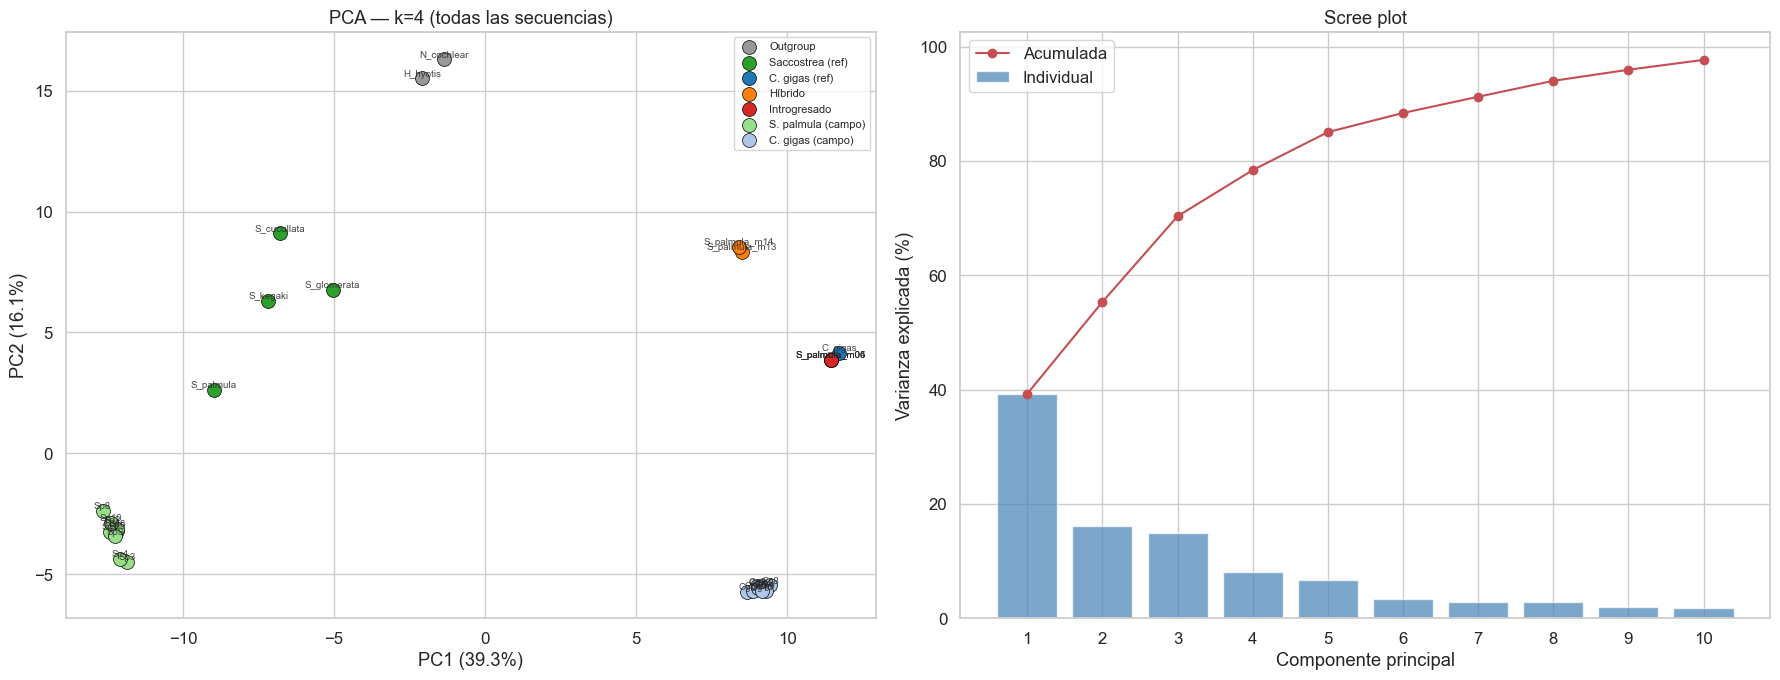

In [11]:
# PCA detallado con el mejor k (probablemente k=4)
K_BEST = 4
mat = build_kmer_matrix(all_seqs, K_BEST)
scaler = StandardScaler()
mat_scaled = scaler.fit_transform(mat.values)

pca = PCA(n_components=min(10, len(mat)))
coords_full = pca.fit_transform(mat_scaled)
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PC1 vs PC2
ax = axes[0]
for g, color in GROUP_COLORS.items():
    mask = [groups[sid] == g for sid in mat.index]
    if any(mask):
        idx_mask = np.where(mask)[0]
        ax.scatter(coords_full[idx_mask, 0], coords_full[idx_mask, 1],
                  c=color, label=g, s=100, edgecolors='black', linewidth=0.5, zorder=3)

for j, sid in enumerate(mat.index):
    ax.annotate(sid, (coords_full[j, 0], coords_full[j, 1]),
               fontsize=7, ha='center', va='bottom', alpha=0.85)

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title(f'PCA — k={K_BEST} (todas las secuencias)')
ax.legend(fontsize=8, loc='best')

# Scree plot
ax = axes[1]
cumvar = np.cumsum(var_exp) * 100
ax.bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, len(var_exp)+1), cumvar, 'ro-', label='Acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Scree plot')
ax.legend()
ax.set_xticks(range(1, len(var_exp)+1))

plt.tight_layout()
plt.savefig('../reports/figures/capa3_pca_detallado.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Capa 4 — K-mers discriminativos

¿Qué fragmentos de secuencia diferencian más a *C. gigas* de *S. palmula*?

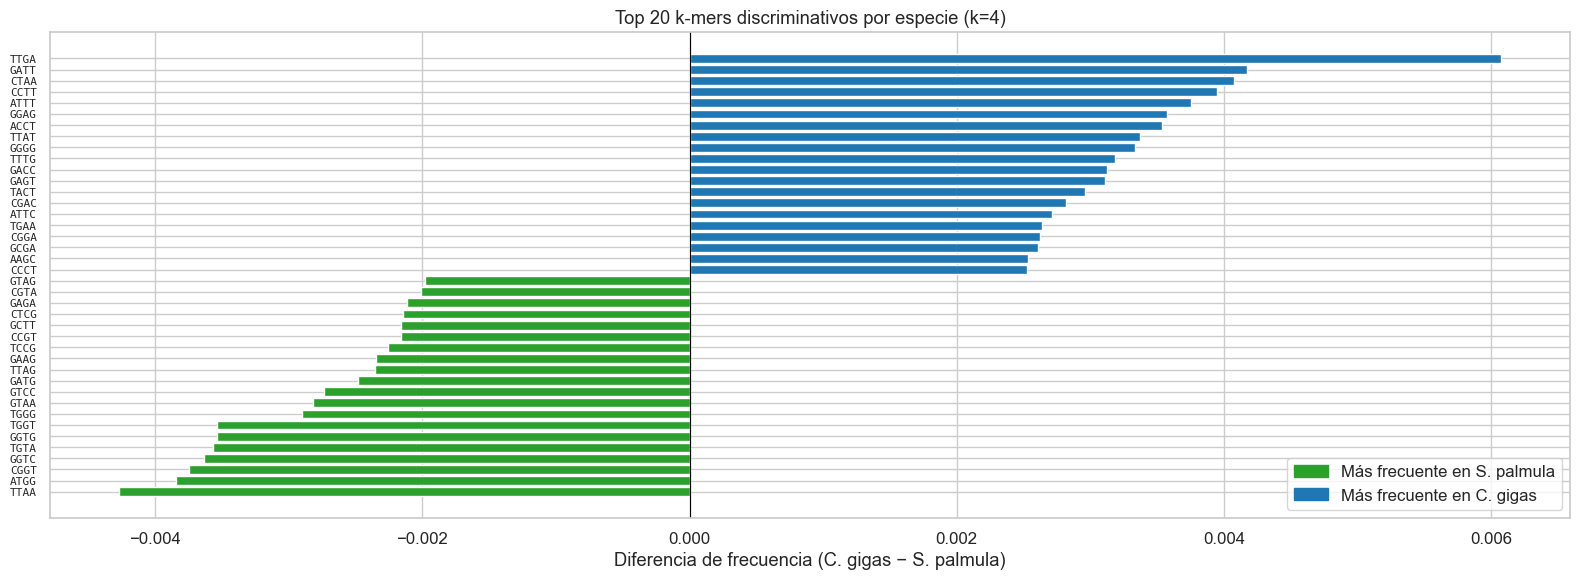

In [12]:
# Comparar frecuencias promedio entre S. palmula (campo) y C. gigas (campo)
K_DISC = 4
mat = build_kmer_matrix(all_seqs, K_DISC)

sp_ids = [s for s in mat.index if groups[s] in ('S. palmula (campo)', 'Saccostrea (ref)')]
cg_ids = [s for s in mat.index if groups[s] in ('C. gigas (campo)', 'C. gigas (ref)')]

mean_sp = mat.loc[sp_ids].mean()
mean_cg = mat.loc[cg_ids].mean()

diff = (mean_cg - mean_sp).sort_values()

fig, ax = plt.subplots(figsize=(16, 6))

n_top = 20
top_sp = diff.head(n_top)  # más frecuentes en S. palmula
top_cg = diff.tail(n_top)  # más frecuentes en C. gigas
top_all = pd.concat([top_sp, top_cg])

colors = ['#2ca02c' if v < 0 else '#1f77b4' for v in top_all.values]
ax.barh(range(len(top_all)), top_all.values, color=colors)
ax.set_yticks(range(len(top_all)))
ax.set_yticklabels(top_all.index, fontsize=8, fontfamily='monospace')
ax.set_xlabel('Diferencia de frecuencia (C. gigas − S. palmula)')
ax.set_title(f'Top {n_top} k-mers discriminativos por especie (k={K_DISC})')
ax.axvline(0, color='black', linewidth=0.8)

legend_patches = [
    mpatches.Patch(color='#2ca02c', label='Más frecuente en S. palmula'),
    mpatches.Patch(color='#1f77b4', label='Más frecuente en C. gigas'),
]
ax.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/capa4_kmers_discriminativos.png', dpi=150, bbox_inches='tight')
plt.show()

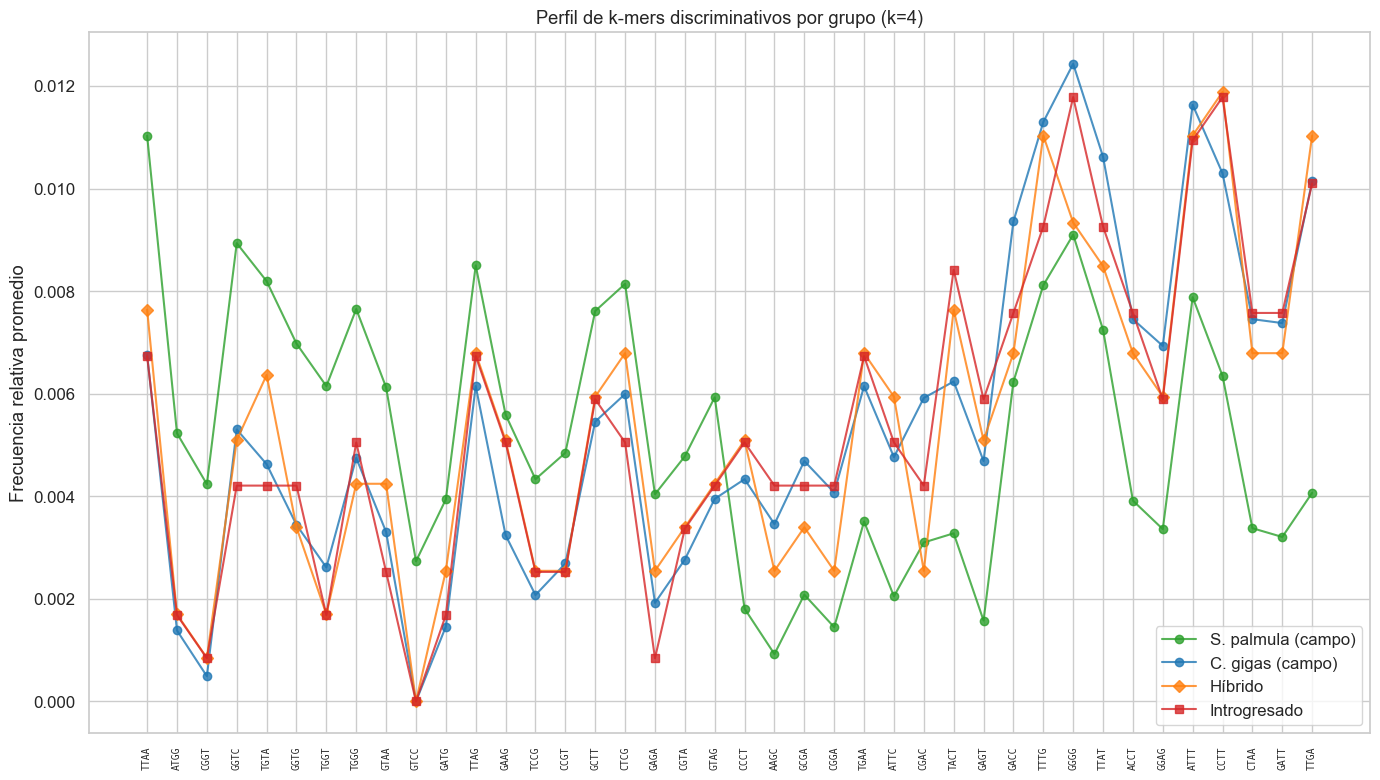

In [13]:
# ¿Dónde caen los híbridos e introgresados respecto a los k-mers discriminativos?
top_kmers = list(top_sp.index) + list(top_cg.index)

hybrid_ids = [s for s in mat.index if groups[s] == 'Híbrido']
intro_ids = [s for s in mat.index if groups[s] == 'Introgresado']

fig, ax = plt.subplots(figsize=(14, 8))

# Promedio de cada grupo para los k-mers top
for label, ids, color, marker in [
    ('S. palmula (campo)', sp_ids, '#2ca02c', 'o'),
    ('C. gigas (campo)', cg_ids, '#1f77b4', 'o'),
    ('Híbrido', hybrid_ids, '#ff7f0e', 'D'),
    ('Introgresado', intro_ids, '#d62728', 's'),
]:
    if not ids:
        continue
    mean_vals = mat.loc[ids, top_kmers].mean()
    ax.plot(range(len(top_kmers)), mean_vals.values,
            marker=marker, label=label, color=color, linewidth=1.5, alpha=0.8)

ax.set_xticks(range(len(top_kmers)))
ax.set_xticklabels(top_kmers, rotation=90, fontsize=7, fontfamily='monospace')
ax.set_ylabel('Frecuencia relativa promedio')
ax.set_title(f'Perfil de k-mers discriminativos por grupo (k={K_DISC})')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/capa4_perfil_hibridos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Resumen y próximos pasos

### Observaciones clave
- [ ] ¿Las longitudes de secuencia difieren significativamente entre archivos? ¿Es un factor confusor?
- [ ] ¿Los outgroups se separan claramente en el PCA?
- [ ] ¿Los híbridos (m13, m14) quedan en posición intermedia entre *C. gigas* y *S. palmula*?
- [ ] ¿Los introgresados (m04–m06) se agrupan con *C. gigas*?
- [ ] ¿Qué valor de k ofrece la mejor separación?

### Próximos pasos
1. **Evaluar factor confusor de longitud** — si las muestras de campo se separan de las referencias solo por longitud, aplicar recorte (Opción A)
2. **Análisis por marcador** — separar 16S, COI e ITS1 y analizar cada uno independientemente
3. **Modelo condicional** — clasificación en dos etapas (mito vs nuclear) para formalizar la detección de hibridación
4. **LDA / kNN con LOOCV** — clasificación supervisada para cuantificar el poder discriminativo